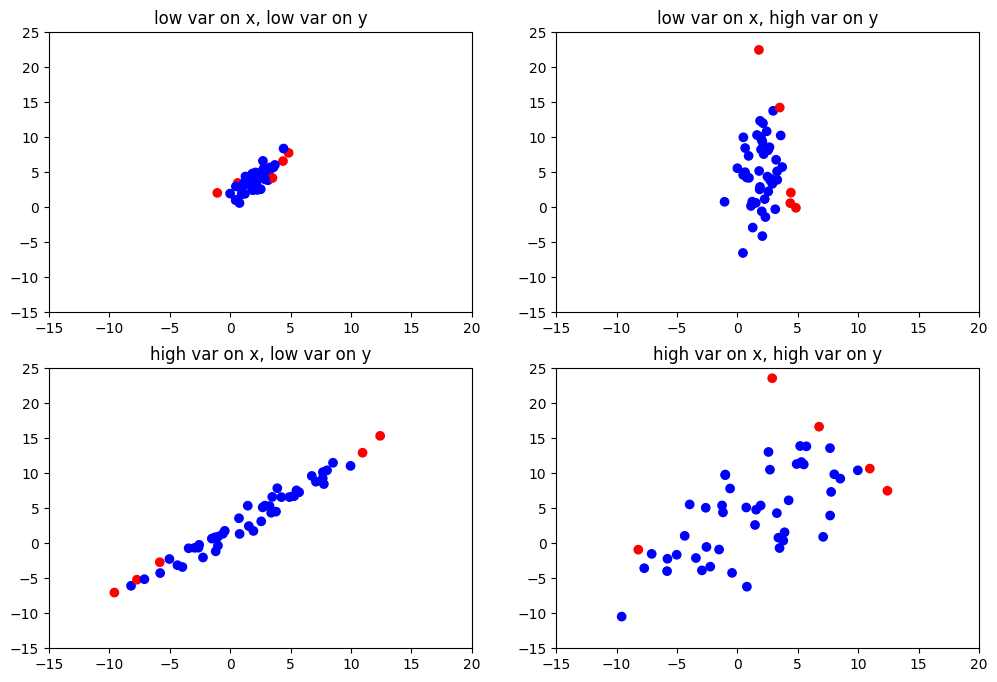

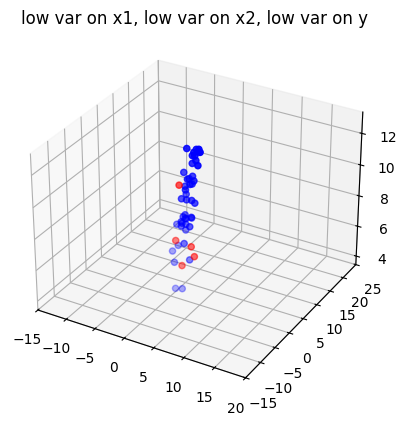

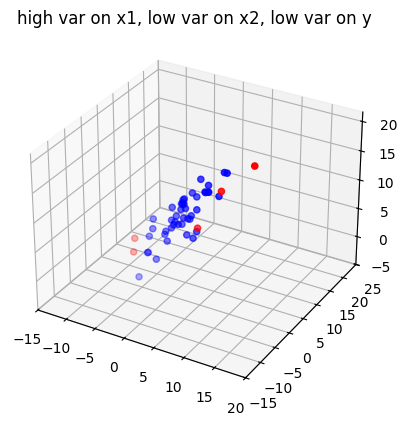

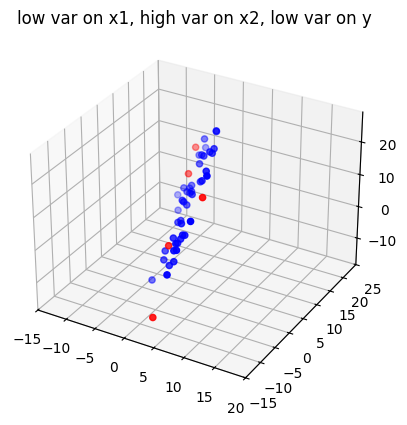

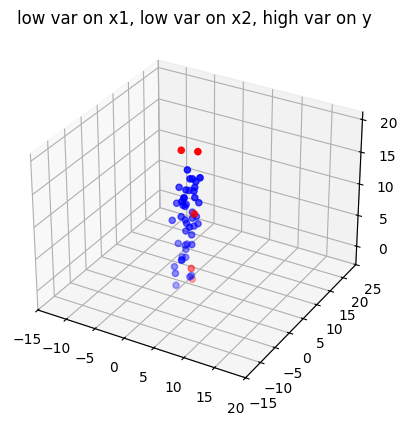

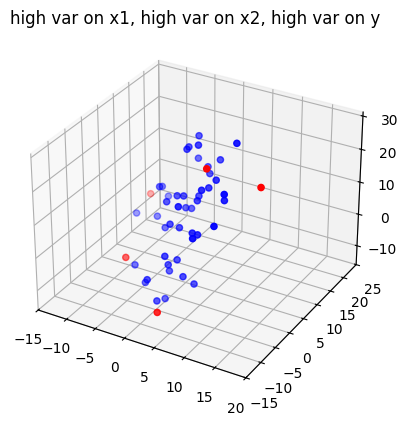

In [6]:
#EX1
import numpy as np
import matplotlib.pyplot as plt

def row_leverage_scores(X):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return (U * U).sum(axis=1)

def top_quantile_mask(values, q=0.90):
    cutoff = np.quantile(values, q)
    return values > cutoff

def mask_to_rb(mask):
    return np.where(mask, 'r', 'b')

def show_1d_model_panels(X_reg, X_hi_x, X_hi_y, X_hi_xy):
    lev_reg, lev_hix, lev_hiy, lev_hixy = map(row_leverage_scores, [X_reg, X_hi_x, X_hi_y, X_hi_xy])
    m_reg, m_hix, m_hiy, m_hixy = map(top_quantile_mask, [lev_reg, lev_hix, lev_hiy, lev_hixy])
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs[0, 0].scatter(X_reg[:, 0], X_reg[:, 1], c=mask_to_rb(m_reg)); axs[0, 0].set_xlim(-15, 20); axs[0, 0].set_ylim(-15, 25); axs[0, 0].set_title("low var on x, low var on y")
    axs[0, 1].scatter(X_hi_y[:, 0], X_hi_y[:, 1], c=mask_to_rb(m_hiy)); axs[0, 1].set_xlim(-15, 20); axs[0, 1].set_ylim(-15, 25); axs[0, 1].set_title("low var on x, high var on y")
    axs[1, 0].scatter(X_hi_x[:, 0], X_hi_x[:, 1], c=mask_to_rb(m_hix)); axs[1, 0].set_xlim(-15, 20); axs[1, 0].set_ylim(-15, 25); axs[1, 0].set_title("high var on x, low var on y")
    axs[1, 1].scatter(X_hi_xy[:, 0], X_hi_xy[:, 1], c=mask_to_rb(m_hixy)); axs[1, 1].set_xlim(-15, 20); axs[1, 1].set_ylim(-15, 25); axs[1, 1].set_title("high var on x, high var on y")
    plt.show()

def show_2d_model_figs(X_all_low, X_hi_x1, X_hi_x2, X_hi_y, X_all_high):
    levs = list(map(row_leverage_scores, [X_all_low, X_hi_x1, X_hi_x2, X_hi_y, X_all_high]))
    masks = [top_quantile_mask(lv, 0.90) for lv in levs]
    titles = ["low var on x1, low var on x2, low var on y", "high var on x1, low var on x2, low var on y", "low var on x1, high var on x2, low var on y", "low var on x1, low var on x2, high var on y", "high var on x1, high var on x2, high var on y"]
    for X, m, t in zip([X_all_low, X_hi_x1, X_hi_x2, X_hi_y, X_all_high], masks, titles):
        fig = plt.figure(); ax = fig.add_subplot(projection='3d')
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=mask_to_rb(m)); ax.set_xlim(-15, 20); ax.set_ylim(-15, 25); plt.title(t); plt.show()

A, B, N = 1, 2, 50
x_low, x_high = np.random.normal(2, 1, N), np.random.normal(2, 5, N)
eps_low, eps_high = np.random.normal(0, 1, N), np.random.normal(0, 5, N)
y_lowx_lowy, y_lowx_highy = A * x_low + B + eps_low, A * x_low + B + eps_high
y_highx_lowy, y_highx_highy = A * x_high + B + eps_low, A * x_high + B + eps_high
X_reg, X_hi_y, X_hi_x, X_hi_xy = np.column_stack([x_low, y_lowx_lowy]), np.column_stack([x_low, y_lowx_highy]), np.column_stack([x_high, y_highx_lowy]), np.column_stack([x_high, y_highx_highy])
show_1d_model_panels(X_reg, X_hi_x, X_hi_y, X_hi_xy)

A2, B2, C2, N2 = 1, 2, 3, 50
x1_low, x1_high, x2_low, x2_high = np.random.normal(2, 1, N2), np.random.normal(2, 5, N2), np.random.normal(2, 1, N2), np.random.normal(2, 5, N2)
eps2_low, eps2_high = np.random.normal(0, 1, N2), np.random.normal(0, 5, N2)
y_all_low, y_hi_x1, y_hi_x2, y_hi_y, y_all_high = A2*x1_low + B2*x2_low + C2 + eps2_low, A2*x1_high + B2*x2_low + C2 + eps2_low, A2*x1_low + B2*x2_high + C2 + eps2_low, A2*x1_low + B2*x2_low + C2 + eps2_high, A2*x1_high + B2*x2_high + C2 + eps2_high
X_all_low, X_hi_x1, X_hi_x2, X_hi_y, X_all_high = np.column_stack([x1_low, x2_low, y_all_low]), np.column_stack([x1_high, x2_low, y_hi_x1]), np.column_stack([x1_low, x2_high, y_hi_x2]), np.column_stack([x1_low, x2_low, y_hi_y]), np.column_stack([x1_high, x2_high, y_all_high])
show_2d_model_figs(X_all_low, X_hi_x1, X_hi_x2, X_hi_y, X_all_high)


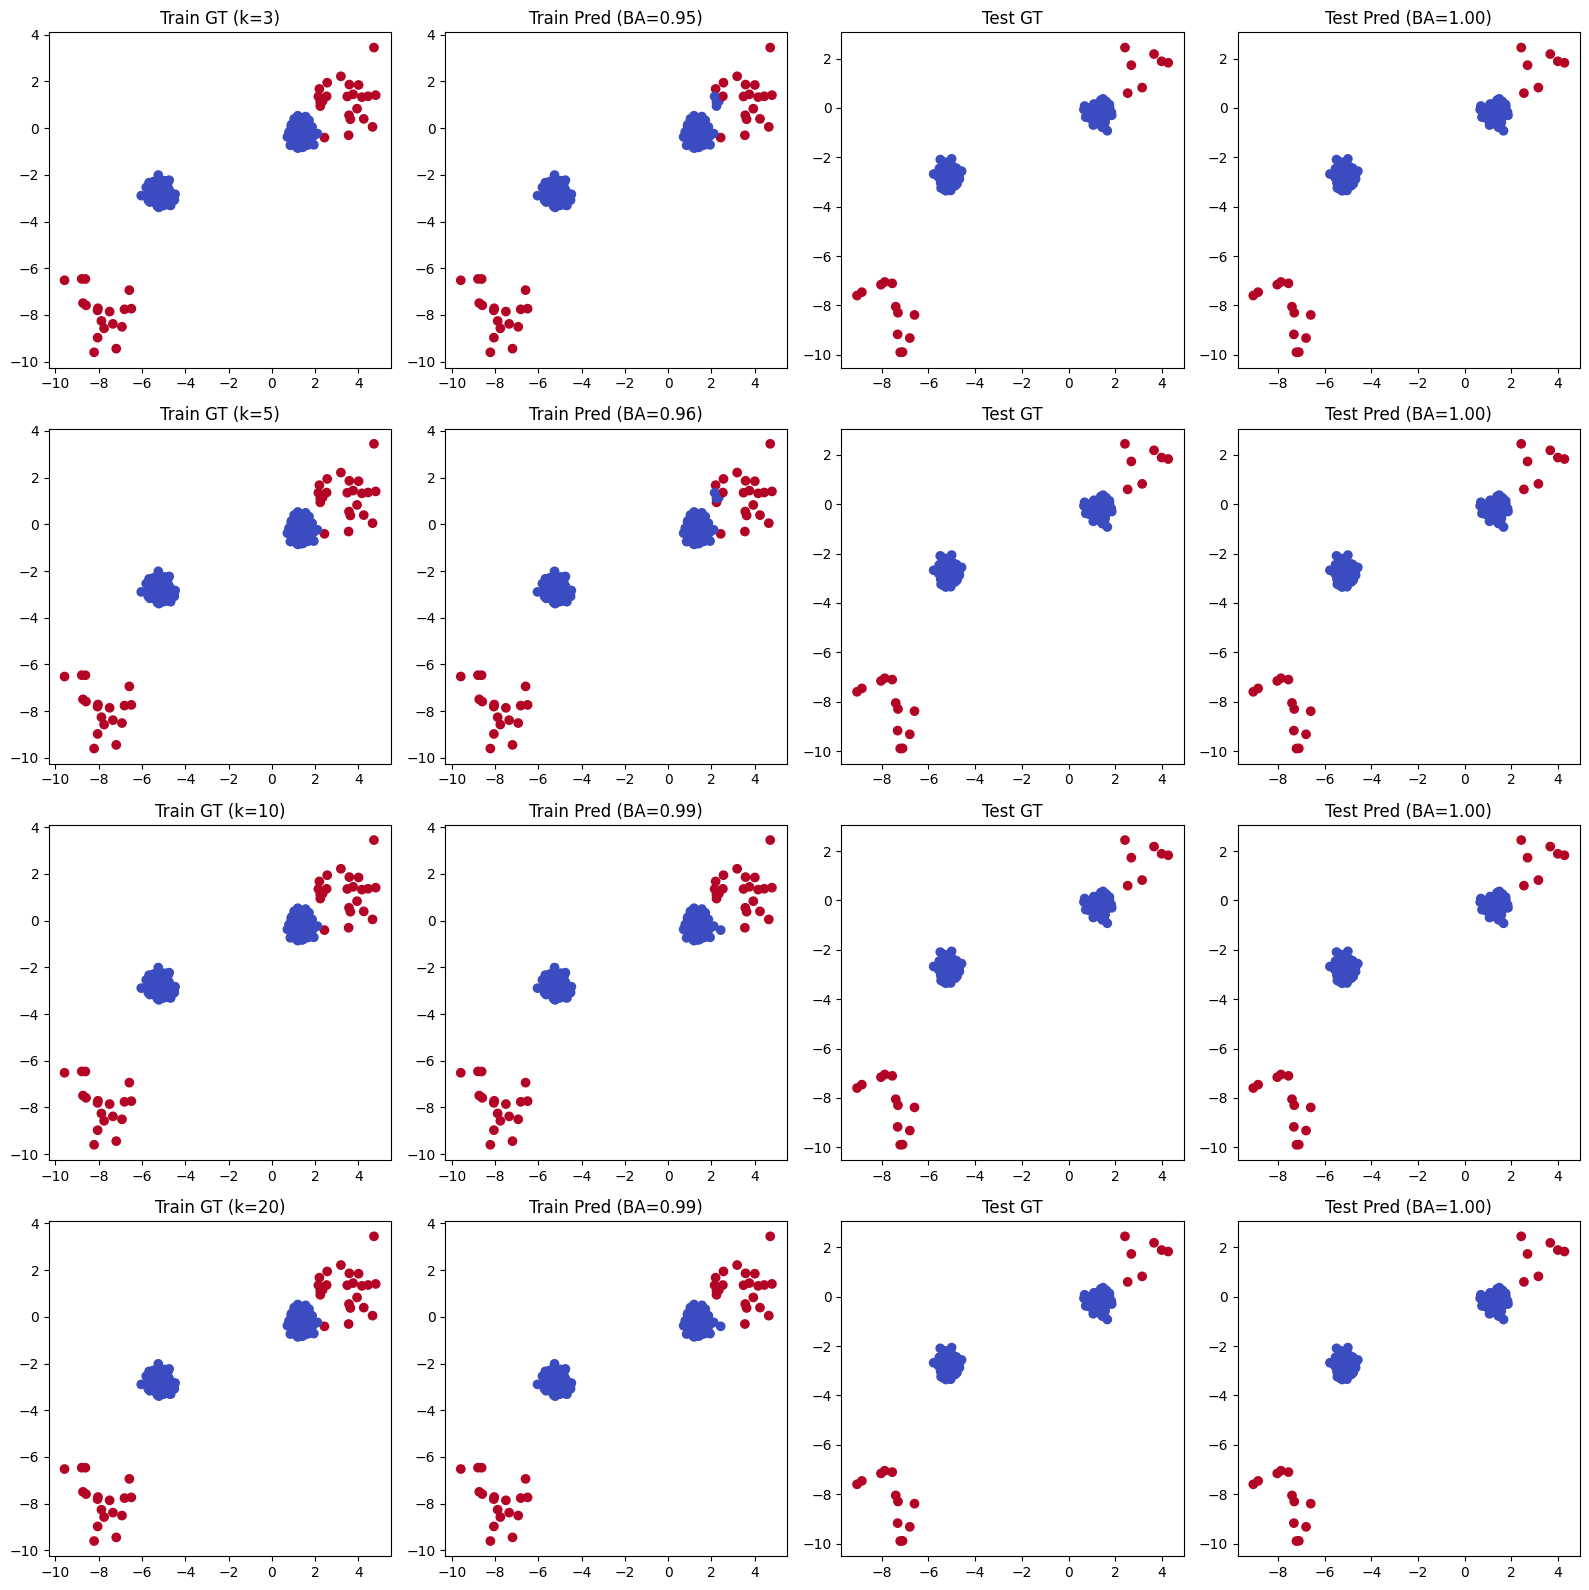

In [8]:
#EX2
import numpy as np
import matplotlib.pyplot as plt
from pyod.utils.data import generate_data_clusters
from pyod.models.knn import KNN
from sklearn.metrics import balanced_accuracy_score

X_train, X_test, y_train, y_test = generate_data_clusters(
    n_train=400, n_test=200, n_clusters=2, n_features=2,
    contamination=0.1, size='same', density='same', dist=0.25,
    random_state=42, return_in_clusters=False)

neighbor_vals = [3, 5, 10, 20]
fig, axes = plt.subplots(len(neighbor_vals), 4, figsize=(16, 4 * len(neighbor_vals)))

for i, nnb in enumerate(neighbor_vals):
    model = KNN(n_neighbors=nnb)
    model.fit(X_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    ba_train = balanced_accuracy_score(y_train, pred_train)
    ba_test = balanced_accuracy_score(y_test, pred_test)

    axes[i, 0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm')
    axes[i, 0].set_title(f'Train GT (k={nnb})')

    axes[i, 1].scatter(X_train[:, 0], X_train[:, 1], c=pred_train, cmap='coolwarm')
    axes[i, 1].set_title(f'Train Pred (BA={ba_train:.2f})')

    axes[i, 2].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm')
    axes[i, 2].set_title('Test GT')

    axes[i, 3].scatter(X_test[:, 0], X_test[:, 1], c=pred_test, cmap='coolwarm')
    axes[i, 3].set_title(f'Test Pred (BA={ba_test:.2f})')

plt.tight_layout()
plt.show()

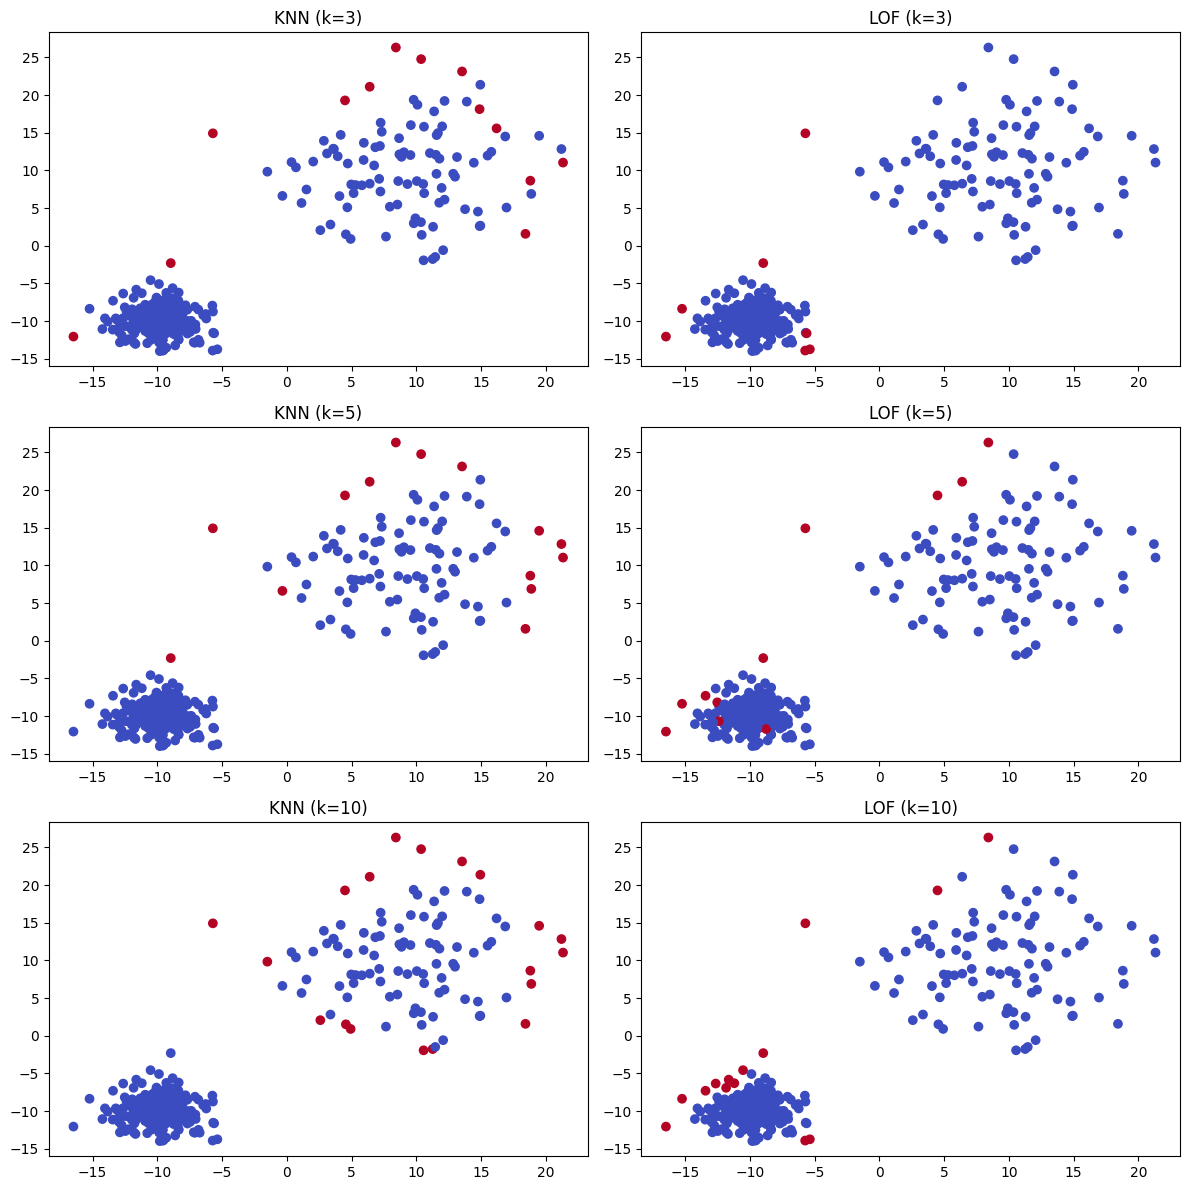

In [10]:
#EX3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from pyod.models.knn import KNN
from pyod.models.lof import LOF

X1, _ = make_blobs(n_samples=200, centers=[(-10, -10)], cluster_std=2, n_features=2, random_state=42)
X2, _ = make_blobs(n_samples=100, centers=[(10, 10)], cluster_std=6, n_features=2, random_state=42)
X = np.vstack((X1, X2))

neighbors_list = [3, 5, 10]
fig, axes = plt.subplots(len(neighbors_list), 2, figsize=(12, 12))

for i, nnb in enumerate(neighbors_list):
    model_knn = KNN(contamination=0.07, n_neighbors=nnb)
    model_lof = LOF(contamination=0.07, n_neighbors=nnb)
    model_knn.fit(X)
    model_lof.fit(X)

    pred_knn = model_knn.predict(X)
    pred_lof = model_lof.predict(X)

    axes[i, 0].scatter(X[:, 0], X[:, 1], c=pred_knn, cmap='coolwarm')
    axes[i, 0].set_title(f'KNN (k={nnb})')

    axes[i, 1].scatter(X[:, 0], X[:, 1], c=pred_lof, cmap='coolwarm')
    axes[i, 1].set_title(f'LOF (k={nnb})')

plt.tight_layout()
plt.show()

In [14]:
#!pip install combo


In [16]:
#EX4
import numpy as np
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.utils.utility import standardizer
from pyod.models.combination import average, maximization

data = loadmat('cardio.mat')
X = data['X']
y = data['y'].ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_test = standardizer(X_train, X_test)

neighbors_range = range(30, 130, 10)
scores_train, scores_test = [], []

for nnb in neighbors_range:
    model = KNN(n_neighbors=nnb)
    model.fit(X_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    ba_tr = balanced_accuracy_score(y_train, y_pred_train)
    ba_te = balanced_accuracy_score(y_test, y_pred_test)
    print(f'k={nnb}: BA_train={ba_tr:.3f}, BA_test={ba_te:.3f}')
    scores_train.append(model.decision_scores_)
    scores_test.append(model.decision_function(X_test))

scores_train = np.array(scores_train).T
scores_test = np.array(scores_test).T

scores_train, scores_test = standardizer(scores_train, scores_test)

avg_scores = average(scores_test)
max_scores = maximization(scores_test)

cont_rate = np.mean(y_test)
thr_avg = np.quantile(avg_scores, 1 - cont_rate)
thr_max = np.quantile(max_scores, 1 - cont_rate)

pred_avg = (avg_scores > thr_avg).astype(int)
pred_max = (max_scores > thr_max).astype(int)

ba_avg = balanced_accuracy_score(y_test, pred_avg)
ba_max = balanced_accuracy_score(y_test, pred_max)

print(f'\nAverage combination BA: {ba_avg:.3f}')
print(f'Max combination BA: {ba_max:.3f}')

k=30: BA_train=0.704, BA_test=0.760
k=40: BA_train=0.720, BA_test=0.794
k=50: BA_train=0.734, BA_test=0.796
k=60: BA_train=0.734, BA_test=0.803
k=70: BA_train=0.735, BA_test=0.803
k=80: BA_train=0.744, BA_test=0.794
k=90: BA_train=0.754, BA_test=0.802
k=100: BA_train=0.754, BA_test=0.810
k=110: BA_train=0.764, BA_test=0.809
k=120: BA_train=0.767, BA_test=0.817

Average combination BA: 0.794
Max combination BA: 0.804
